<a href="https://colab.research.google.com/github/leonidasf300/OUU2026/blob/main/LeonSerna_OUU_project_v0_simple_feeder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simple feeder to do a simple model

# Installing libraries

In [4]:
pip install pandapower[all]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.0/330.0 kB 23.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.9/292.9 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 27.0 MB/s eta 0:00:00
 

# Importing libraries

In [13]:
import pandapower as pp
import pandapower.shortcircuit as sc
import pandapower as pp
import pandapower.shortcircuit as sc
import pandas as pd
import warnings

# Creating IEC MG

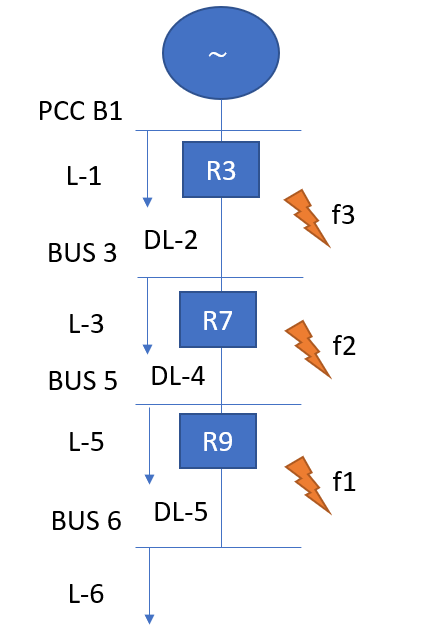

In [2]:


def create_iec_microgrid():
    # Crear red vacía
    net = pp.create_empty_network(f_hz=60.0)

    # ================= BUSES =================
    # Red de utilidad
    bus_utility = pp.create_bus(net, vn_kv=120.0, name="Utility 120kV")

    # Nivel de distribución 25 kV
    bus_pcc = pp.create_bus(net, vn_kv=25.0, name="PCC B1")
    bus2 = pp.create_bus(net, vn_kv=25.0, name="BUS 2")
    #bus3 = pp.create_bus(net, vn_kv=25.0, name="BUS 3")
    #bus4 = pp.create_bus(net, vn_kv=25.0, name="BUS 4")
    bus5 = pp.create_bus(net, vn_kv=25.0, name="BUS 5")
    bus6 = pp.create_bus(net, vn_kv=25.0, name="BUS 6")

    # Buses de Generadores (Baja Tensión)
    #bus_dg1 = pp.create_bus(net, vn_kv=2.4, name="Terminal DG1")
    #bus_dg2 = pp.create_bus(net, vn_kv=2.4, name="Terminal DG2")
    #bus_dg3 = pp.create_bus(net, vn_kv=0.575, name="Terminal DG3")
    #bus_dg4 = pp.create_bus(net, vn_kv=0.575, name="Terminal DG4")

    # ================= GRID EXTERNO =================
    # S_sc = 1000 MVA según Tabla 1
    pp.create_ext_grid(net, bus_utility, s_sc_max_mva=1000.0, rx_max=0.1, name="Utility Grid")

    # ================= TRANSFORMADORES =================
    # vkr_percent = 0.00375 * 100 = 0.375%
    # vk_percent = sqrt(0.00375^2 + 0.01^2) * 100 = 1.068%
    # Calc: vkr=R1*100 | vk=sqrt(R1**2+X1**2)*100 | pfe=(1/Rm)*Sn*1e3 | i0=sqrt((1/Rm)**2+(1/Xm)**2)*100


    # TR-1: 15 MVA, 120/25 kV
    pp.create_transformer_from_parameters(net, hv_bus=bus_utility, lv_bus=bus_pcc, sn_mva=15.0,
                                          vn_hv_kv=120.0, vn_lv_kv=25.0, vkr_percent=0.375,
                                          vk_percent=1.068, pfe_kw=30, i0_percent=0.2828, name="TR-1")
    """
    # TR-2 y TR-3: 12 MVA, 25/2.4 kV
    pp.create_transformer_from_parameters(net, hv_bus=bus2, lv_bus=bus_dg1, sn_mva=12.0,
                                          vn_hv_kv=25.0, vn_lv_kv=2.4, vkr_percent=0.375,
                                          vk_percent=1.068, pfe_kw=24, i0_percent=0.2828, name="TR-2")
    pp.create_transformer_from_parameters(net, hv_bus=bus3, lv_bus=bus_dg2, sn_mva=12.0,
                                          vn_hv_kv=25.0, vn_lv_kv=2.4, vkr_percent=0.375,
                                          vk_percent=1.068, pfe_kw=24, i0_percent=0.2828, name="TR-3")

    # TR-4 y TR-5: 10 MVA, 25/0.575 kV
    pp.create_transformer_from_parameters(net, hv_bus=bus4, lv_bus=bus_dg3, sn_mva=10.0,
                                          vn_hv_kv=25.0, vn_lv_kv=0.575, vkr_percent=0.375,
                                          vk_percent=1.068, pfe_kw=20, i0_percent=0.2828, name="TR-4")
    pp.create_transformer_from_parameters(net, hv_bus=bus6, lv_bus=bus_dg4, sn_mva=10.0,
                                          vn_hv_kv=25.0, vn_lv_kv=0.575, vkr_percent=0.375,
                                          vk_percent=1.068, pfe_kw=20, i0_percent=0.2828, name="TR-5")
    """

    # ================= LÍNEAS DE DISTRIBUCIÓN =================
    # R1 = 0.413 ohm/km, L1 = 3.32e-3 H/km -> X1 = 2*pi*60*3.32e-3 = 1.251 ohm/km
    # C1 = 5.01e-9 F/km
    line_params = {
    "r_ohm_per_km": 0.413,
    "x_ohm_per_km": 1.251,
    "c_nf_per_km": 5.01,
    "r0_ohm_per_km": 0.1153, # Datos de la Tabla 5
    "x0_ohm_per_km": 0.396,  # Calculado de L0
    "c0_nf_per_km": 11.33,   # Datos de la Tabla 5
    "max_i_ka": 1.0
}

    #pp.create_line_from_parameters(net, from_bus=bus_pcc, to_bus=bus3, length_km=30.0, name="DL-1", **line_params)
    pp.create_line_from_parameters(net, from_bus=bus_pcc, to_bus=bus2, length_km=30.0, name="DL-2", **line_params)
    #pp.create_line_from_parameters(net, from_bus=bus2, to_bus=bus4, length_km=30.0, name="DL-3", **line_params)
    pp.create_line_from_parameters(net, from_bus=bus2, to_bus=bus5, length_km=30.0, name="DL-4", **line_params)
    pp.create_line_from_parameters(net, from_bus=bus5, to_bus=bus6, length_km=30.0, name="DL-5", **line_params)

    # Interruptores de lazo (Loop breakers) - Normalmente abiertos para operación radial
    #pp.create_switch(net, bus=bus2, element=bus4, et="b", closed=False, name="CB_LOOP 1")
    #pp.create_switch(net, bus=bus4, element=bus6, et="b", closed=False, name="CB_LOOP 2")

    # ================= GENERADORES DISTRIBUIDOS =================
    # DG1, DG2: Sincrónicos (9 MVA, xd'' = 0.177)
    #pp.create_gen(net, bus_dg1, p_mw=8.1, vm_pu=1.0, sn_mva=9.0, vn_kv=2.4, xdss_pu=0.177, rdss_ohm=0.0, cos_phi=0.9, name="DG1")
    #pp.create_gen(net, bus_dg2, p_mw=8.1, vm_pu=1.0, sn_mva=9.0, vn_kv=2.4, xdss_pu=0.177, rdss_ohm=0.0, cos_phi=0.9, name="DG2")

    # DG3: Inversor Eólico (6 MVA, xd'' = 0.252)
    #pp.create_gen(net, bus_dg3, p_mw=5.4, vm_pu=1.0, sn_mva=6.0, vn_kv=0.575, xdss_pu=0.252, rdss_ohm=0.0, cos_phi=0.9, name="DG3")

    # DG4: DFIG Eólico (9 MVA, Ls + Lr' = 0.34)
    #pp.create_gen(net, bus_dg4, p_mw=8.1, vm_pu=1.0, sn_mva=9.0, vn_kv=0.575, xdss_pu=0.34, rdss_ohm=0.0, cos_phi=0.9, name="DG4")

    # ================= CARGAS =================
    # Total de 22 MW y 10 MVAR dividido en 6 cargas
    p_load = 22.0 / 6.0
    q_load = 10.0 / 6.0

    pp.create_load(net, bus_pcc, p_mw=p_load, q_mvar=q_load, name="L-1")
    pp.create_load(net, bus2, p_mw=p_load, q_mvar=q_load, name="L-2")
    #pp.create_load(net, bus3, p_mw=p_load, q_mvar=q_load, name="L-3")
    #pp.create_load(net, bus4, p_mw=p_load, q_mvar=q_load, name="L-4")
    pp.create_load(net, bus5, p_mw=p_load, q_mvar=q_load, name="L-5")
    pp.create_load(net, bus6, p_mw=p_load, q_mvar=q_load, name="L-6")

    return net

# Inicializar red
net = create_iec_microgrid()

# ================= ANÁLISIS DE CORTOCIRCUITO =================
# Ejecutar cortocircuito trifásico según norma IEC 60909
# case="max" para calcular corrientes máximas de falla
sc.calc_sc(net, case="max", ip=True, ith=True, branch_results=True)

# Imprimir resultados en buses (corriente de cortocircuito subtransitoria ikss)
print("--- Resultados de Cortocircuito en Buses (ikss en kA) ---")
print(net.res_bus_sc[['ikss_ka', 'ip_ka']])

/usr/local/lib/python3.12/dist-packages/pandapower/build_branch.py:1434: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  power_station_unit = trafo_df.power_station_unit.fillna(False).values.astype(bool)
/usr/local/lib/python3.12/dist-packages/pandapower/build_branch.py:1434: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  power_station_unit = trafo_df.power_station_unit.fillna(False).values.astype(bool)


--- Resultados de Cortocircuito en Buses (ikss en kA) ---
     ikss_ka      ip_ka
0   4.811252  11.880038
1  13.921352  30.463729
2   0.390529   0.766535
3   0.198024   0.388142
4   0.132641   0.259863


In [3]:
net.bus

,name,vn_kv,type,zone,in_service,geo
0,Utility 120kV,120.0,b,None,True,None
1,PCC B1,25.0,b,None,True,None
2,BUS 2,25.0,b,None,True,None
3,BUS 5,25.0,b,None,True,None
4,BUS 6,25.0,b,None,True,None


In [5]:
#ICC = ICC4.copy()

#columns: main
#rows: back ups
   #R7,R6,R4,R2
#R7
#R6
#R4
#R2
BACKUP = [[0,0,0,0],
          [1,0,0,0],
          [1,1,0,0],
          [1,1,1,0]]


# BACKUP = [[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
#           [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0],
#           [1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
#           [0,0,0,0,0,1,0,0,0,0,0,0,0,0,1],
#           [0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],
#           [0,0,0,0,0,0,1,1,0,0,0,0,0,0,0],
#           [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
#           [0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],#M8, B11
#           [0,0,0,0,0,0,0,0,0,0,0,0,0,1,0],
#           [0,0,0,0,0,1,0,0,0,0,0,0,0,0,1],
#           [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
#           [0,0,0,0,1,0,1,0,0,0,0,0,0,0,0],
#           [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
#           [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
#           [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]]


#R7
#R6
#R4
#R2
CT_PS = [[1200,1],#7
          [400,0.5],#6
          [400,0.5],#4
          [400,0.5]]#2



# principal = [[1,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
#               [0,0,1,1,0,0,0,0,0,0,0,0,0,0,0],
#               [0,0,0,0,1,1,0,0,0,0,0,0,0,0,0],
#               [0,0,0,0,0,0,0,1,0,0,0,1,0,0,0],
#               [0,0,0,0,0,0,0,0,1,1,0,0,0,0,0],]


# faults = {"F1":"DL-5", "F2":"DL-4", "F3":"DL-2", "F4":"DL-1", "F5":"DL-3"}
#             7,6,4,2
principal = [[0,0,0,1],
              [0,0,1,0],
              [0,1,0,0]]



faults = {"F1":"DL-5", "F2":"DL-4", "F3":"DL-2"}

In [6]:
headers = ["DG0", "DG1", "DG2", "DG3","DG4"]
rows = ["OM1","OM2","OM3","OM4"]

matrix = [[1,0,0,0,0],
          [1,1,1,1,1],
          [1,1,1,0,0],
          [0,1,1,1,1]]

OMS = {
    (rows[i], headers[j]): matrix[i][j]
    for i in range(len(rows))
    for j in range(len(headers))
}



In [20]:

Cindex={"STI":{"A":0.05,"B":0.04,"C":0},
        "SI":{"A":0.14,"B":0.02,"C":0}}
        # "VI":{"A":13.5,"B":1,"C":0},
        # "EI":{"A":80,"B":2,"C":0},
        # "LTI":{"A":120,"B":1,"C":0},
        # "UI":{"A":315.2,"B":2.5,"C":0},
        # "IEEE-LTI":{"A":0.086,"B":0.05,"C":0.185},
        # "IEEE-LTVI":{"A":28.55,"B":2,"C":0.712},
        # "IEEE-LTEI":{"A":64.07,"B":2,"C":0.25},
        # "IEEE-MI":{"A":0.0515,"B":0.02,"C":0.114},
        # "IEEE-VI":{"A":19.61,"B":2,"C":0.491},
        # "IEEE-EI":{"A":28.2,"B":2,"C":0.1217},
        # "IEEE-STI":{"A":0.16758,"B":0.02,"C":0.11858},
        # "IEEE-STEI":{"A":1.281,"B":2,"C":0.005}}
C=["STI", "SI"]#, "VI","EI","LTI","IEEE-LTI","IEEE-LTVI","IEEE-LTEI","IEEE-MI","IEEE-VI","IEEE-EI","IEEE-STI","IEEE-STEI"]


# Function calculate_sc_percentage

In [21]:
def calculate_sc_percentage(net, nombre_linea, pasos=10):
    # 1. Identificar la línea original
    line_idx = net.line[net.line.name == nombre_linea].index[0]
    bus_inicial = net.line.at[line_idx, "from_bus"]
    bus_final = net.line.at[line_idx, "to_bus"]
    L_total = net.line.at[line_idx, "length_km"]
    params = {
        "r_ohm_per_km": net.line.at[line_idx, "r_ohm_per_km"],
        "x_ohm_per_km": net.line.at[line_idx, "x_ohm_per_km"],
        "c_nf_per_km": net.line.at[line_idx, "c_nf_per_km"],
        "max_i_ka": net.line.at[line_idx, "max_i_ka"]
    }

    # 2. Desactivar la línea original
    net.line.at[line_idx, "in_service"] = False

    resultados = []

    # 3. Iterar cada 10% (o el paso definido)
    for i in range(1, pasos):
        porcentaje = i / pasos
        distancia_falla = L_total * porcentaje

        # Crear bus temporal de falla
        f_bus = pp.create_bus(net, vn_kv=net.bus.at[bus_inicial, "vn_kv"], name=f"Falla_{int(porcentaje*100)}%")

        # Crear los dos tramos de línea que conectan al punto de falla
        l1 = pp.create_line_from_parameters(net, bus_inicial, f_bus, distancia_falla, name="tramo_A", **params)
        l2 = pp.create_line_from_parameters(net, f_bus, bus_final, L_total - distancia_falla, name="tramo_B", **params)

        # 4. Ejecutar SC con branch_results=True para ver qué ven los relés en los extremos
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            sc.calc_sc(net, bus=f_bus, branch_results=True)

        # Guardar datos: I_total en falla, I que ve Relé inicial (l1), I que ve Relé final (l2)
        # resultados.append({
        #     "Porcentaje": f"{int(porcentaje*100)}%",
        #     "I_falla_total": net.res_bus_sc.ikss_ka.at[f_bus],
        #     "I_Relé_Front": net.res_line_sc.ikss_ka.at[l1],
        #     "I_Relé_Back": net.res_line_sc.ikss_ka.at[l2]
        # })
        resultados.append(net.res_line_sc.ikss_ka.at[l1])

        # Limpiar para no acumular líneas en el modelo
        pp.drop_lines(net, [l1, l2])
        pp.drop_buses(net, [f_bus])

    # Restaurar línea original
    net.line.at[line_idx, "in_service"] = True
    #return pd.DataFrame(resultados)
    return resultados



# Beta equation

$$
 \beta_{ficd} = \frac{A_c}{(\frac{ICC_{ifd}}{Ipickup_i})^{B_c}-1}
$$

In [26]:
Findex=[f"F{i+1}" for i in range(3)]
Rindex=[f"R{i+1}" for i in range(4)]

BETA=dict()
B=dict()

for relay in range(len(Rindex)):
  for fault in range(len(Findex)):
    for curve in range(len(C)):
      dsteps = 3
      steps = [i / dsteps for i in range(1, dsteps)]
      ICC_fid = calculate_sc_percentage(net, nombre_linea=faults[Findex[fault]], pasos=dsteps)
      for index, ICC2 in enumerate(ICC_fid):
        #PSMif=(ICC[fault][relay])/(CT_PS[relay][0])/CT_PS[relay][1]
        PSMif=(ICC2)/(CT_PS[relay][0])/CT_PS[relay][1]
        #BETA[Findex[fault],Rindex[relay],C[curve]]=(Cindex[C[curve]]["A"])/((PSMif**Cindex[C[curve]]["B"])-1)
        BETA[Findex[fault],Rindex[relay],C[curve],steps[index]]=(Cindex[C[curve]]["A"])/((PSMif**Cindex[C[curve]]["B"])-1)

for main in range(len(Rindex)):
  for backup in range(len(Rindex)):
    B[Rindex[main],Rindex[backup]] = BACKUP[main][backup]


In [23]:
# Convert the BETA dictionary to a list of dictionaries for DataFrame creation
beta_data = []
for key, value in BETA.items():
    falla, rele, curva, distancia = key
    beta_data.append({
        'Falla': falla,
        'Rele': rele,
        'Curva': curva,
        'Distancia': distancia,
        'Beta': value
    })

# Create the DataFrame
beta_df = pd.DataFrame(beta_data)

# Display the first few rows of the DataFrame
display(beta_df.head())


,Falla,Rele,Curva,Distancia,Beta
0,F1,R1,STI,0.1,-0.168405
1,F1,R1,STI,0.2,-0.166933
2,F1,R1,STI,0.3,-0.165533
3,F1,R1,STI,0.4,-0.164189
4,F1,R1,STI,0.5,-0.162887


In [24]:
beta_df[beta_df["Rele"]=="R1"]

,Falla,Rele,Curva,Distancia,Beta
0,F1,R1,STI,0.1,-0.168405
1,F1,R1,STI,0.2,-0.166933
2,F1,R1,STI,0.3,-0.165533
3,F1,R1,STI,0.4,-0.164189
4,F1,R1,STI,0.5,-0.162887
5,F1,R1,STI,0.6,-0.161611
6,F1,R1,STI,0.7,-0.160349
7,F1,R1,STI,0.8,-0.159087
8,F1,R1,STI,0.9,-0.157809
9,F1,R1,SI,0.1,-0.866921


In [25]:
1/0

ZeroDivisionError: division by zero

In [ ]:
def ICC_calculate(net,fault,relay,distance):



In [ ]:

def calculate_beta():
    headers = ["f","i","c","d","ICC_ifd", "Ipickup_i"]



    rows = []

    for i in range(n):
        cuadrado = i ** 2
        cubo = i ** 3

        rows.append([i, cuadrado, cubo])

    return pd.DataFrame(rows, columns=headers)

df = calcular_datos(5)
print(df)

In [ ]:


def calculate_beta_dict(ICC, Cindex, CT_PS, faults, principal, rows, num_percentages=10):
    """
    Calcula el valor de beta para cada combinación de relé principal, falla, curva y distancia.

    Args:
        ICC (dict): Diccionario de corrientes de cortocircuito, donde las claves son (OM, porcentaje_distancia) y los valores son matrices de corrientes (falla x relé).
        Cindex (dict): Diccionario de parámetros de curva (A, B, C).
        CT_PS (list): Lista de parámetros de transformadores de corriente [CT_primario, ajuste_pickup] para cada relé.
        faults (dict): Diccionario de fallas, donde la clave es el nombre de la falla y el valor es el nombre de la línea.
        principal (list): Matriz que indica si un relé es principal para una falla específica.
        rows (list): Lista de modos operativos (OM).
        num_percentages (int): Número de pasos para la distancia porcentual (e.g., 10 para 0.1 a 0.9).

    Returns:
        dict: Un diccionario con los valores de beta. Las claves son (OM, porcentaje, falla_key, relay_idx, curve_key).
    """
    beta_dict = {}
    percentages = [round(i / num_percentages, 2) for i in range(1, num_percentages)]

    for om in rows:
        for p in percentages:
            # Check if this (om, p) combination exists in ICC. If not, skip.
            if (om, p) not in ICC:
                print(f"Warning: ICC data for OM '{om}' and percentage {p} not found. Skipping.")
                continue

            icc_matrix_for_om_p = ICC[(om, p)]
            f_keys = list(faults.keys())

            for f_idx, f_key in enumerate(f_keys):
                if f_idx >= len(icc_matrix_for_om_p): # Ensure fault index is valid for the ICC matrix
                    print(f"Warning: Fault index {f_idx} out of bounds for ICC matrix at OM '{om}', percentage {p}. Skipping.")
                    continue

                icc_for_fault_f = icc_matrix_for_om_p[f_idx] # This is a list of 15 currents for the current fault

                for relay_idx in range(len(CT_PS)): # Iterate through all 15 relays
                    # Check if this relay is a 'principal' relay for the current fault
                    if f_idx < len(principal) and relay_idx < len(principal[f_idx]) and principal[f_idx][relay_idx] == 1:
                        ICCifd = icc_for_fault_f[relay_idx] # Current for this specific relay, fault, OM, and percentage
                        ct_primary = CT_PS[relay_idx][0]
                        pickup_setting = CT_PS[relay_idx][1]

                        Ipickupi = ct_primary * pickup_setting

                        # Ensure Ipickupi is not zero to avoid division by zero
                        if Ipickupi == 0:
                            # If pickup is 0, relay is not configured to trip, or current is infinite at pickup
                            # Assign a very high value or handle as undefined for beta calculation.
                            # For simplicity, if pickup is zero, we assume no valid beta can be calculated.
                            beta = float('nan') # Not a Number
                        else:
                            for curve_key, curve_params in Cindex.items():
                                Ac = curve_params["A"]
                                Bc = curve_params["B"]

                                ratio = ICCifd / Ipickupi

                                if ratio <= 1:
                                    beta = 0.0 # Relay does not operate below pickup current
                                else:
                                    denominator = (ratio**Bc) - 1
                                    if denominator == 0:
                                        beta = float('inf') # Infinite operating time
                                    else:
                                        beta = Ac / denominator

                                # Store beta value
                                # Using a tuple as key for (OM, percentage, fault_key, relay_index, curve_key)
                                beta_dict[(om, p, f_key, relay_idx, curve_key)] = beta
                    # else: This relay is not principal for this fault, so we don't calculate beta for it

    return beta_dict


In [ ]:
# Call the calculate_beta_dict function to generate the beta values
beta_dict = calculate_beta_dict(
    ICC=ICC,
    Cindex=Cindex,
    CT_PS=CT_PS,
    faults=faults,
    principal=principal,
    rows=rows,
    num_percentages=10
)

print("Generated beta_dict with total entries:", len(beta_dict))

# Display the first 10 entries of the beta_dict for demonstration
print("First 10 entries of beta_dict:")
for i, (key, value) in enumerate(beta_dict.items()):
    if i >= 10:
        break
    print(f"  {key}: {value}")


In [ ]:
def obtener_mascara_reles(falla_idx, principal, backup):
    """
    Retorna una lista de 15 elementos (0 o 1).
    1 si el relé es principal o respaldo para la falla 'falla_idx'.
    """
    mask = [0] * 15
    for j in range(15):
        # Si es relé principal
        if principal[falla_idx][j] == 1:
            mask[j] = 1
            # Añadir todos sus respaldos (mirando la matriz BACKUP)
            for k in range(15):
                if backup[j][k] == 1:
                    mask[k] = 1
    return mask

def configurar_om(net, om_name, OMS_dict):
    """
    Enciende o apaga la Utility (DG0) y los DGs (DG1-DG4) según la matriz OMS.
    """
    # DG0 corresponde a la Utility grid (ext_grid)
    if len(net.ext_grid) > 0:
        net.ext_grid.in_service = bool(OMS_dict[(om_name, "DG0")])

    # Generadores Distribuidos (Asumiendo que se llaman "DG1", "DG2", etc.)
    for i in range(1, 5):
        nombre_dg = f"DG{i}"
        estado = bool(OMS_dict[(om_name, nombre_dg)])
        idx_dg = net.gen[net.gen.name == nombre_dg].index
        if len(idx_dg) > 0:
            net.gen.loc[idx_dg, "in_service"] = estado

In [ ]:
import pandapower.shortcircuit as sc
import pandapower as pp

def generar_diccionario_icc(net, faults, principal, BACKUP, rows, OMS, pasos=10):
    ICC = {}

    # Generar porcentajes: [0.1, 0.2, ..., 0.9]
    porcentajes = [i / pasos for i in range(1, pasos)]

    # Mapeo para iterar las fallas en orden (0 a 4)
    lista_fallas = list(faults.items()) # [('F1', 'DL-5'), ('F2', 'DL-4'), ...]

    # 1. Iterar sobre cada Modo Operativo
    for om in rows:
        configurar_om(net, om, OMS)

        # 2. Iterar sobre cada paso (porcentaje)
        for p in porcentajes:
            matriz_falla_om = [] # Contendrá las 5 filas (una por falla)

            # 3. Iterar sobre las 5 líneas (F1 a F5)
            for f_idx, (f_key, f_linea) in enumerate(lista_fallas):

                # Obtener la máscara para forzar a 0 los relés que no actúan
                mask = obtener_mascara_reles(f_idx, principal, BACKUP)

                # --- PREPARAR LA FALLA EN PANDAPOWER ---
                line_idx = net.line[net.line.name == f_linea.strip()].index[0]
                bus_inicial = net.line.at[line_idx, "from_bus"]
                bus_final = net.line.at[line_idx, "to_bus"]
                L_total = net.line.at[line_idx, "length_km"]
                distancia_falla = L_total * p

                params = {
                    "r_ohm_per_km": net.line.at[line_idx, "r_ohm_per_km"],
                    "x_ohm_per_km": net.line.at[line_idx, "x_ohm_per_km"],
                    "c_nf_per_km": net.line.at[line_idx, "c_nf_per_km"],
                    "max_i_ka": net.line.at[line_idx, "max_i_ka"]
                }

                net.line.at[line_idx, "in_service"] = False
                f_bus = pp.create_bus(net, vn_kv=net.bus.at[bus_inicial, "vn_kv"], name="Falla_Temp")

                l1 = pp.create_line_from_parameters(net, bus_inicial, f_bus, distancia_falla, name="tramo_A", **params)
                l2 = pp.create_line_from_parameters(net, f_bus, bus_final, L_total - distancia_falla, name="tramo_B", **params)

                # --- EJECUTAR CORTOCIRCUITO ---
                sc.calc_sc(net, bus=f_bus, branch_results=True)

                # --- LECTURA DE LOS 15 RELÉS ---
                # AQUI ESTÁ LA LÍNEA EDITADA: pasamos f_linea
                corrientes_reales = leer_corrientes_15_reles(net, l1, l2, f_linea)

                # --- APLICAR LA MÁSCARA ---
                # Multiplicamos la corriente real por la máscara (1 o 0)
                fila_resultados = [
                    round(corrientes_reales[i] * mask[i], 3)
                    for i in range(15)
                ]

                matriz_falla_om.append(fila_resultados)

                # --- LIMPIAR TOPOLOGÍA ---
                pp.drop_lines(net, [l1, l2])
                pp.drop_buses(net, [f_bus])
                net.line.at[line_idx, "in_service"] = True

            # Guardar la matriz de 5x15 en el diccionario con la clave (OM, p)
            ICC[(om, round(p, 2))] = matriz_falla_om

    return ICC

In [ ]:

def leer_corrientes_15_reles(net, l1, l2, nombre_linea_fallada):
    """
    Lee las corrientes de las tablas de resultados de forma segura.
    Evita el AttributeError comprobando si la columna existe.
    """
    corrientes = [0.0] * 15
    lineas_nombres = ["DL-1", "DL-2", "DL-3", "DL-4", "DL-5"]

    # 1. LECTURA DE RELÉS DE LÍNEA (R1 a R10)
    for i, nombre in enumerate(lineas_nombres):
        idx_r_fwd = i * 2
        idx_r_rev = i * 2 + 1

        # Validar que res_line_sc tiene la columna ikss_ka
        if "ikss_ka" in net.res_line_sc.columns:
            if nombre == nombre_linea_fallada.strip():
                if l1 in net.res_line_sc.index:
                    corrientes[idx_r_fwd] = net.res_line_sc.at[l1, "ikss_ka"] * 1000
                if l2 in net.res_line_sc.index:
                    corrientes[idx_r_rev] = net.res_line_sc.at[l2, "ikss_ka"] * 1000
            else:
                line_idx_lista = net.line[net.line.name == nombre].index
                if len(line_idx_lista) > 0:
                    line_idx = line_idx_lista[0]
                    if line_idx in net.res_line_sc.index:
                        val = net.res_line_sc.at[line_idx, "ikss_ka"] * 1000
                        corrientes[idx_r_fwd] = val
                        corrientes[idx_r_rev] = val

    # 2. LECTURA DE RELÉS DE GENERADOR (R11 a R14)
    for i in range(1, 5): # DG1 a DG4
        nombre_dg = f"DG{i}"
        dg_idx_lista = net.gen[net.gen.name == nombre_dg].index
        if len(dg_idx_lista) > 0:
            dg_idx = dg_idx_lista[0]
            # Validar que el DG está en servicio y la tabla tiene datos
            if net.gen.at[dg_idx, "in_service"] and "ikss_ka" in net.res_gen_sc.columns:
                if dg_idx in net.res_gen_sc.index:
                    corrientes[9 + i] = net.res_gen_sc.at[dg_idx, "ikss_ka"] * 1000

    # 3. LECTURA DEL RELÉ PRINCIPAL / UTILITY (R15)
    if len(net.ext_grid) > 0:
        ext_idx = net.ext_grid.index[0]
        if net.ext_grid.at[ext_idx, "in_service"] and "ikss_ka" in net.res_ext_grid_sc.columns:
            if ext_idx in net.res_ext_grid_sc.index:
                corrientes[14] = net.res_ext_grid_sc.at[ext_idx, "ikss_ka"] * 1000

    # Limpieza final: Convertir cualquier NaN que se haya colado a 0.0
    corrientes = [0.0 if pd.isna(x) else x for x in corrientes]

    return corrientes

In [ ]:


# ==========================================
# 2. EJECUCIÓN DE LA SIMULACIÓN
# ==========================================
# Ejecutamos la función asumiendo 10 pasos (0.1 a 0.9)
# Recuerda que la variable 'net' debe existir en tu entorno.
ICC = generar_diccionario_icc(
    net=net,
    faults=faults,
    principal=principal,
    BACKUP=BACKUP,
    rows=rows,
    OMS=OMS,
    pasos=10
)

# ==========================================
# 3. IMPRESIÓN DEL RESULTADO (Formato Deseado)
# ==========================================
# Para verificar exactamente la salida de ("OM1", 0.5)
target_key = ("OM1", 0.5)

if target_key in ICC:
    print(f"###################### {target_key[0]} #######################################")
    print(f"ICC = {{({repr(target_key[0])}, {target_key[1]} ): ")
    print("      [")

    matriz_resultado = ICC[target_key]
    for i, fila in enumerate(matriz_resultado):
        # Formatear la coma final dependiendo de si es la última fila o no
        terminacion = "]," if i < len(matriz_resultado) - 1 else "]"
        print(f"       {fila}{terminacion}")

    print("      ]}")
else:
    print(f"La clave {target_key} no se encontró en el diccionario.")

In [ ]:
import json

# Ejecutamos la simulación
ICC = generar_diccionario_icc(net, faults, principal, BACKUP, rows, OMS, pasos=10)

# 1. Transformar las llaves de tupla ("OM1", 0.5) a string "OM1_0.5"
ICC_json_compatible = {f"{k[0]}_{k[1]}": v for k, v in ICC.items()}

# 2. Guardar el archivo JSON
nombre_archivo = "resultados_cortocircuito.json"
with open(nombre_archivo, "w") as archivo_json:
    json.dump(ICC_json_compatible, archivo_json, indent=4)

print(f"¡Resultados guardados exitosamente en {nombre_archivo}!")

# end

In [ ]:
1/0

In [ ]:
net.res_bus_sc

In [ ]:
net.bus

In [ ]:
net.res_line_sc

In [ ]:
sc.calc_sc(net, bus=2, fault='3ph', case='max',
           branch_results=True, r_fault_ohm=0.0, x_fault_ohm=0.0)

In [ ]:
net.res_line_sc

# Calculate SC porcentual

In [ ]:


def calcular_sc_porcentual(net, nombre_linea, pasos=10):
    # 1. Identificar la línea original
    line_idx = net.line[net.line.name == nombre_linea].index[0]
    bus_inicial = net.line.at[line_idx, "from_bus"]
    bus_final = net.line.at[line_idx, "to_bus"]
    L_total = net.line.at[line_idx, "length_km"]
    params = {
        "r_ohm_per_km": net.line.at[line_idx, "r_ohm_per_km"],
        "x_ohm_per_km": net.line.at[line_idx, "x_ohm_per_km"],
        "c_nf_per_km": net.line.at[line_idx, "c_nf_per_km"],
        "max_i_ka": net.line.at[line_idx, "max_i_ka"]
    }

    # 2. Desactivar la línea original
    net.line.at[line_idx, "in_service"] = False

    resultados = []

    # 3. Iterar cada 10% (o el paso definido)
    for i in range(1, pasos):
        porcentaje = i / pasos
        distancia_falla = L_total * porcentaje

        # Crear bus temporal de falla
        f_bus = pp.create_bus(net, vn_kv=net.bus.at[bus_inicial, "vn_kv"], name=f"Falla_{int(porcentaje*100)}%")

        # Crear los dos tramos de línea que conectan al punto de falla
        l1 = pp.create_line_from_parameters(net, bus_inicial, f_bus, distancia_falla, name="tramo_A", **params)
        l2 = pp.create_line_from_parameters(net, f_bus, bus_final, L_total - distancia_falla, name="tramo_B", **params)

        # 4. Ejecutar SC con branch_results=True para ver qué ven los relés en los extremos
        sc.calc_sc(net, bus=f_bus, branch_results=True)

        # Guardar datos: I_total en falla, I que ve Relé inicial (l1), I que ve Relé final (l2)
        resultados.append({
            "Porcentaje": f"{int(porcentaje*100)}%",
            "I_falla_total": net.res_bus_sc.ikss_ka.at[f_bus],
            "I_Relé_Front": net.res_line_sc.ikss_ka.at[l1],
            "I_Relé_Back": net.res_line_sc.ikss_ka.at[l2]
        })

        # Limpiar para no acumular líneas en el modelo
        pp.drop_lines(net, [l1, l2])
        pp.drop_buses(net, [f_bus])

    # Restaurar línea original
    net.line.at[line_idx, "in_service"] = True
    return pd.DataFrame(resultados)

# Uso:
df_falla_dl1 = calcular_sc_porcentual(net, "DL-4")
print(df_falla_dl1)

In [ ]:
0.760799   +  0.488610

In [ ]:
df_falla_dl1 = calcular_sc_porcentual(net, "DL-1")
print(df_falla_dl1)

In [ ]:
df_falla_dl1 = calcular_sc_porcentual(net, "DL-2")
print(df_falla_dl1)

In [ ]:
df_falla_dl1 = calcular_sc_porcentual(net, "DL-3")
print(df_falla_dl1)

In [ ]:
df_falla_dl1 = calcular_sc_porcentual(net, "DL-4")
print(df_falla_dl1)

In [ ]:
df_falla_dl1 = calcular_sc_porcentual(net, "DL-5")
print(df_falla_dl1)

In [ ]:
# --- MODO ISLA (Islanding) ---
# 1. Desactivar la red externa (asumiendo que solo tienes una)
net.ext_grid.in_service = False

# 2. Correr tu función de fallas porcentuales
df_falla_isla_dl1 = calcular_sc_porcentual(net, "DL-1")

# 3. Mostrar resultados y restaurar
print("Resultados en Modo Isla (Sin Utility):")
print(df_falla_isla_dl1)

net.ext_grid.in_service = True
